In [51]:
import os
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np
from sklearn.model_selection import train_test_split

dataset_path = 'E:\Fourth Year\First Semester\Generative Adversarial Networks\Assignments\Assign4\Dataset'

def load_images(folder_path, target_size=(100, 100), rotate_angle=-90):
    images = []
    labels = []
    label_mapping = {'0': 0, '1': 1}
    
    for label in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label)
        label_value = label_mapping[label]
        
        for filename in os.listdir(label_path):
            img_path = os.path.join(label_path, filename)
            
            img = load_img(img_path, target_size=target_size)

            if label == '0':
                img = img.rotate(rotate_angle)
            
            img_array = img_to_array(img)
            
            img_array /= 255.0

            images.append(img_array)
            labels.append(label_value)
            
    return np.array(images), np.array(labels)

images, labels = load_images(dataset_path)
X_Train, X_Test, Y_Train, Y_Test = train_test_split(images, labels, test_size=0.2, shuffle=True)

In [52]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from keras import backend as K

original_dim = 100 * 100 * 3
intermediate_dim = 800
latent_dim = 200
num_classes = 2

inputs = keras.Input(shape=(original_dim,))
class_label = layers.Input(shape=(num_classes,))
concatenated_input = layers.concatenate([inputs, class_label])

h = layers.Dense(intermediate_dim, activation='relu')(concatenated_input)
z_mean = layers.Dense(latent_dim)(h)
z_log_sigma = layers.Dense(latent_dim)(h)

def sampling(args):
    z_mean, z_log_sigma = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim), mean=0., stddev=0.1)
    return z_mean + K.exp(z_log_sigma) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_sigma])

concatenated_z = layers.concatenate([z, class_label])

# Create encoder
encoder = keras.Model([inputs, class_label], concatenated_z)

# Create decoder
latent_inputs = keras.Input(shape=(latent_dim + num_classes,))
x = layers.Dense(intermediate_dim, activation='relu')(latent_inputs)
outputs = layers.Dense(original_dim, activation='sigmoid')(x)
decoder = keras.Model(latent_inputs, outputs)

# VAE model
outputs = decoder(encoder(inputs))
vae = keras.Model([inputs, class_label], outputs)

# Custom loss function
reconstruction_loss = keras.losses.mean_squared_error(inputs, outputs)
reconstruction_loss *= original_dim
kl_loss = 1 + z_log_sigma - K.square(z_mean) - K.exp(z_log_sigma)
kl_loss = K.sum(kl_loss, axis=-1)
kl_loss *= -0.5
vae_loss = K.mean(reconstruction_loss + kl_loss)

# Compile VAE model with custom loss
vae.add_loss(vae_loss)
vae.compile(optimizer='adam', loss=None) 

X_Train = X_Train.reshape((len(X_Train), np.prod(X_Train.shape[1:])))
Y_Train = keras.utils.to_categorical(Y_Train, num_classes)

vae.fit([X_Train, Y_Train], X_Train, epochs=10, batch_size=32)

Epoch 1/10
6/6 [==============================] - 4s 532ms/step - loss: 1927376011264.0000
Epoch 2/10
6/6 [==============================] - 3s 523ms/step - loss: 1181271457792.0000
Epoch 3/10
6/6 [==============================] - 3s 504ms/step - loss: 5555870208.0000
Epoch 4/10
6/6 [==============================] - 3s 523ms/step - loss: 5252510.0000
Epoch 5/10
6/6 [==============================] - 3s 496ms/step - loss: 3643707.2500
Epoch 6/10
6/6 [==============================] - 3s 498ms/step - loss: 375782.6250
Epoch 7/10
6/6 [==============================] - 3s 505ms/step - loss: 288021.0312
Epoch 8/10
6/6 [==============================] - 3s 516ms/step - loss: 228379.5781
Epoch 9/10
6/6 [==============================] - 3s 495ms/step - loss: 196463.1719
Epoch 10/10
6/6 [==============================] - 3s 494ms/step - loss: 184794.3281


1/1 [==============================] - 0s 63ms/step


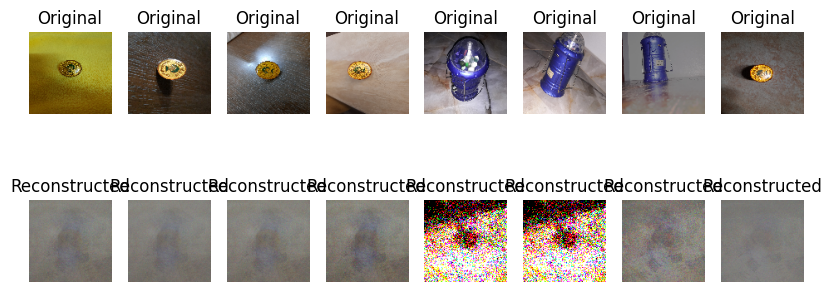

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

X_Test = X_Test.reshape((len(X_Test), np.prod(X_Test.shape[1:])))
Y_Test = keras.utils.to_categorical(Y_Test, num_classes)
encoder_output = encoder.predict([X_Test, Y_Test])

# The encoder_output is a list containing [z_mean, z_log_sigma, z]
z_mean_output, z_log_sigma_output, z_output = encoder_output

# Number of images to visualize
num_images = 8

# Create a function to update the displayed images based on the slider value
def update_images(value):
    global num_images
    num_images = round(float(value))
    updated_original_images = X_Test[:num_images]
    # Concatenate class labels to the sampled latent vector
    updated_class_labels = Y_Test[:num_images]
    updated_z_output = np.concatenate([z_output[:num_images], updated_class_labels], axis=1)
    updated_reconstructed_images = decoder.predict(updated_z_output)
    display_images(updated_original_images, updated_reconstructed_images)

# Function to display original and reconstructed images
def display_images(original_images, reconstructed_images):
    n = len(original_images)

    # Clear existing axes
    for ax in axes.flatten():
        ax.clear()

    for i in range(n):
        # Display original images
        axes[0, i].imshow(original_images[i].reshape(100, 100, 3))
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

        # Display reconstructed images
        axes[1, i].imshow(reconstructed_images[i].reshape(100, 100, 3), cmap='gray')
        axes[1, i].set_title('Reconstructed')
        axes[1, i].axis('off')

    canvas.draw()

# Create the main GUI window
root = tk.Tk()
root.title("Image Viewer")

# Create a Matplotlib figure to embed in the tkinter window
fig, axes = plt.subplots(2, num_images, figsize=(10, 4))
canvas = FigureCanvasTkAgg(fig, master=root)
canvas_widget = canvas.get_tk_widget()
canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=1)

# Create a slider for selecting the number of images
slider_label = tk.Label(root, text="Number of Images:")
slider_label.pack(pady=10)
slider = ttk.Scale(root, from_=1, to=num_images, orient=tk.HORIZONTAL, command=update_images)
slider.set(num_images)
slider.pack(pady=10)


# Start the tkinter main loop
root.mainloop()

1/1 [==============================] - 0s 25ms/step


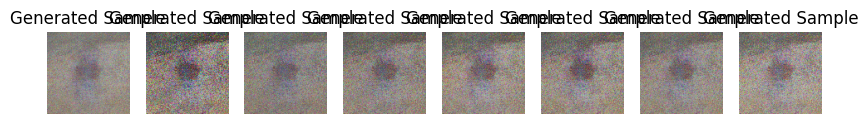

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

desired_class = 0

# Create a function to update the displayed images based on the slider value
def update_images(value):
    global num_images
    num_images = round(float(value))
    
    specific_class_label = np.eye(num_classes)[desired_class]
    specific_class_label = np.tile(specific_class_label, (num_images, 1))
    
    random_latent_vectors = np.random.normal(size=(num_images, latent_dim))
    conditioned_latent_vectors = np.concatenate([random_latent_vectors, specific_class_label], axis=1)
    updated_generated_samples = decoder.predict(conditioned_latent_vectors)

    display_images(updated_generated_samples)

# Function to display generated samples
def display_images(generated_samples):
    n = len(generated_samples)

    # Clear existing axes
    for ax in axes:
        ax.clear()

    for i in range(n):
        # Reshape the generated sample to the original dimensions
        reshaped_sample = generated_samples[i].reshape((100, 100, 3))

        # Display generated samples
        axes[i].imshow(reshaped_sample)
        axes[i].set_title('Generated Sample')
        axes[i].axis('off')

    canvas.draw()

# Create the main GUI window
root = tk.Tk()
root.title("Image Viewer")

# Create a Matplotlib figure to embed in the tkinter window
fig, axes = plt.subplots(1, num_images, figsize=(10, 2))
canvas = FigureCanvasTkAgg(fig, master=root)
canvas_widget = canvas.get_tk_widget()
canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=1)

# Create a slider for selecting the number of images
slider_label = tk.Label(root, text="Number of Images:")
slider_label.pack(pady=10)
slider = ttk.Scale(root, from_=1, to=num_images, orient=tk.HORIZONTAL, command=update_images)
slider.set(num_images)
slider.pack(pady=10)

# Start the tkinter main loop
root.mainloop()